# Byte‑Pair Encoding (BPE) on Trigram Datasets
This notebook loads trigram‑frequency datasets for three collections (*lastfm*, *suno*, *udio*), runs a Byte‑Pair Encoding algorithm to discover
the most common adjacent token pairs, and visualises the top merged patterns.

In [2]:
import os, json, itertools, collections, math, gzip, pickle, pathlib
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as tqdm
import re 

# 📂 Filesystem layout
BASE_DIR = '/workspace/dataset_2'          # top‑level containing lastfm/ suno/ udio/
COLLECTIONS = ['lastfm', 'suno', 'udio']

INIT_TOKEN = '<init>'
END_TOKEN  = '<end>'

In [3]:
def load_chord_sequences(collection_name):
    """Return a list of full chord streams for one collection, using the
       clean roman‑numeral symbols directly."""
    seqs = []
    root = os.path.join(BASE_DIR, collection_name)

    for song_id in os.listdir(root):
        fp = os.path.join(root, song_id, f"{song_id}_normalized.json")
        if not os.path.isfile(fp):
            continue

        try:
            with open(fp) as f:
                data = json.load(f)
            chords = data.get("chords", [])
            if not chords:
                continue

            tokens = [ch.get("roman_numeral") for ch in chords if ch.get("roman_numeral")]
            if not tokens:
                continue

            seqs.append(tuple([INIT_TOKEN] + tokens + [END_TOKEN]))
        except Exception as e:
            print("⚠️", fp, e)

    return seqs

def to_trigram_tokens(chord_seq):
    trigram_list = []
    for i in range(len(chord_seq) - 2):
        tri = tuple(chord_seq[i:i+3])          # ('IV','I','v')
        if len(set(tri)) == 3:             # all chords different
            trigram_list.append(tri)
    return tuple(trigram_list)

In [4]:
def get_pair_frequencies(seq_counts):
    pair_freq = Counter()
    for tokens, cnt in seq_counts:
        for i in range(len(tokens) - 1):
            pair_freq[(tokens[i], tokens[i+1])] += cnt
    return pair_freq

def merge_pair(seq_counts, pair_to_merge, new_tok):
    a, b = pair_to_merge
    merged = []
    for tokens, cnt in seq_counts:
        new_tokens = []
        i = 0
        while i < len(tokens):
            if i < len(tokens) - 1 and tokens[i] == a and tokens[i+1] == b:
                new_tokens.append(new_tok)
                i += 2
            else:
                new_tokens.append(tokens[i])
                i += 1
        merged.append((tuple(new_tokens), cnt))
    return merged

def byte_pair_encoding(seq_counts, num_merges=150):
    merge_rules, merge_history = {}, []
    for m in range(num_merges):
        pf = get_pair_frequencies(seq_counts)
        if not pf:
            break
        (best_pair, freq) = pf.most_common(1)[0]
        new_tok = f'MERGE_{m}'
        merge_rules[new_tok] = best_pair
        merge_history.append((best_pair, freq))
        seq_counts = merge_pair(seq_counts, best_pair, new_tok)
    return merge_rules, merge_history

def expand_token(tok, rules):
    if tok not in rules:
        return [tok]
    a, b = rules[tok]
    return expand_token(a, rules) + expand_token(b, rules)

In [5]:
NUM_MERGES = 150  # 🔧 tweak
results = {}
for col in tqdm.tqdm(COLLECTIONS):
    print(f'\n➤ Processing {col}')
    chord_streams = load_chord_sequences(col)
    seq_counts = [(to_trigram_tokens(seq), 1) for seq in chord_streams]  # weight 1 per song occurrence

    merge_rules, merge_history = byte_pair_encoding(seq_counts, num_merges=NUM_MERGES)
    results[col] = {'rules': merge_rules, 'history': merge_history}

    # Display top 20 merges
    def pretty(trigram):
        return '(' + ', '.join(trigram) + ')'

    print('   Top merged trigram‑pairs:')
    for idx, ((a, b), freq) in enumerate(merge_history[:20], 1):
        if isinstance(a, str):  # it's a MERGE_x label → expand to base trigrams
            a_tokens = expand_token(a, merge_rules)
        else:
            a_tokens = [a]

        if isinstance(b, str):
            b_tokens = expand_token(b, merge_rules)
        else:
            b_tokens = [b]

        # now every element in a_tokens / b_tokens is a real 3‑chord trigram
        left  = ' '.join('(' + ', '.join(t) + ')' for t in a_tokens)
        right = ' '.join('(' + ', '.join(t) + ')' for t in b_tokens)

        print(f"{idx:2d}. [{left}] → [{right}] — {freq}")

  0%|          | 0/3 [00:00<?, ?it/s]


➤ Processing lastfm


 33%|███▎      | 1/3 [03:15<06:30, 195.49s/it]

   Top merged trigram‑pairs:
 1. [(IV, I, V)] → [(I, V, IV)] — 741
 2. [(I, v, IV)] → [(v, IV, I)] — 601
 3. [(I, IV, V)] → [(IV, V, I)] — 503
 4. [(I, v, i)] → [(v, i, I)] — 469
 5. [(I, i, v)] → [(i, v, I)] — 468
 6. [(I, bVI, bVII)] → [(bVI, bVII, I)] — 466
 7. [(I, IV, i)] → [(IV, i, I)] — 454
 8. [(I, vi, IV)] → [(vi, IV, I)] — 435
 9. [(I, i, IV)] → [(i, IV, I)] — 423
10. [(bVI, bVII, i)] → [(bVII, i, bVI)] — 415
11. [(I, III, IV)] → [(III, IV, I)] — 396
12. [(IV, I, V) (I, V, IV)] → [(V, IV, I)] — 389
13. [(I, IV, v)] → [(IV, v, I)] — 383
14. [(I, bVII, IV)] → [(bVII, IV, I)] — 357
15. [(I, v, V)] → [(v, V, I)] — 352
16. [(bVI, I, i)] → [(I, i, bVI)] — 350
17. [(I, V, IV)] → [(V, IV, I)] — 347
18. [(I, V, v)] → [(V, v, I)] — 341
19. [(bVI, i, I)] → [(i, I, bVI)] — 332
20. [(I, i, bVII)] → [(i, bVII, I)] — 330

➤ Processing suno


 67%|██████▋   | 2/3 [05:57<02:56, 176.05s/it]

   Top merged trigram‑pairs:
 1. [(vi, IV, I)] → [(IV, I, V)] — 2635
 2. [(I, V, vi)] → [(V, vi, IV)] — 2543
 3. [(V, IV, I)] → [(IV, I, V)] — 2296
 4. [(I, IV, V)] → [(IV, V, I)] — 1489
 5. [(I, bVI, bVII)] → [(bVI, bVII, I)] — 1473
 6. [(bVI, bVII, i)] → [(bVII, i, bVI)] — 1241
 7. [(IV, I, vi)] → [(I, vi, IV)] — 1216
 8. [(I, V, IV)] → [(V, IV, I) (IV, I, V)] — 1213
 9. [(i, bVI, III)] → [(bVI, III, bVII)] — 1122
10. [(I, V, vi) (V, vi, IV)] → [(vi, IV, I) (IV, I, V)] — 1083
11. [(IV, V, vi)] → [(V, vi, IV)] — 1047
12. [(I, V, IV)] → [(V, IV, I)] — 1011
13. [(I, bVI, III)] → [(bVI, III, bVII)] — 993
14. [(III, bVII, i)] → [(bVII, i, bVI)] — 951
15. [(VI, IV, I)] → [(IV, I, V)] — 924
16. [(vi, IV, V)] → [(IV, V, I)] — 896
17. [(I, V, vi)] → [(V, vi, I)] — 894
18. [(I, bVI, V)] → [(bVI, V, I)] — 862
19. [(V, I, vi)] → [(I, vi, IV)] — 799
20. [(III, bVII, I)] → [(bVII, I, bVI)] — 779

➤ Processing udio


100%|██████████| 3/3 [08:11<00:00, 163.71s/it]

   Top merged trigram‑pairs:
 1. [(I, V, IV)] → [(V, IV, I)] — 522
 2. [(I, IV, V)] → [(IV, V, I)] — 479
 3. [(i, bVI, bVII)] → [(bVI, bVII, i)] — 469
 4. [(I, vi, IV)] → [(vi, IV, I)] — 344
 5. [(I, bVI, bVII)] → [(bVI, bVII, I)] — 342
 6. [(i, bVI, III)] → [(bVI, III, i)] — 335
 7. [(I, v, IV)] → [(v, IV, I)] — 329
 8. [(bVI, i, III)] → [(i, III, bVI)] — 321
 9. [(IV, I, V)] → [(I, V, vi)] — 313
10. [(bVI, i, bVII)] → [(i, bVII, bVI)] — 311
11. [(V, vi, IV)] → [(vi, IV, I)] — 304
12. [(I, IV, v)] → [(IV, v, I)] — 292
13. [(i, bVI, III)] → [(bVI, III, bVII)] — 274
14. [(I, i, v)] → [(i, v, I)] — 270
15. [(I, v, i)] → [(v, i, I)] — 265
16. [(I, IV, i)] → [(IV, i, I)] — 264
17. [(i, bVI, iv)] → [(bVI, iv, i)] — 257
18. [(bVI, bVII, i)] → [(bVII, i, bVI)] — 243
19. [(I, i, IV)] → [(i, IV, I)] — 242
20. [(IV, I, V)] → [(I, V, IV) (V, IV, I)] — 236


/tmp/ipykernel_1543500/4010002394.py:64: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


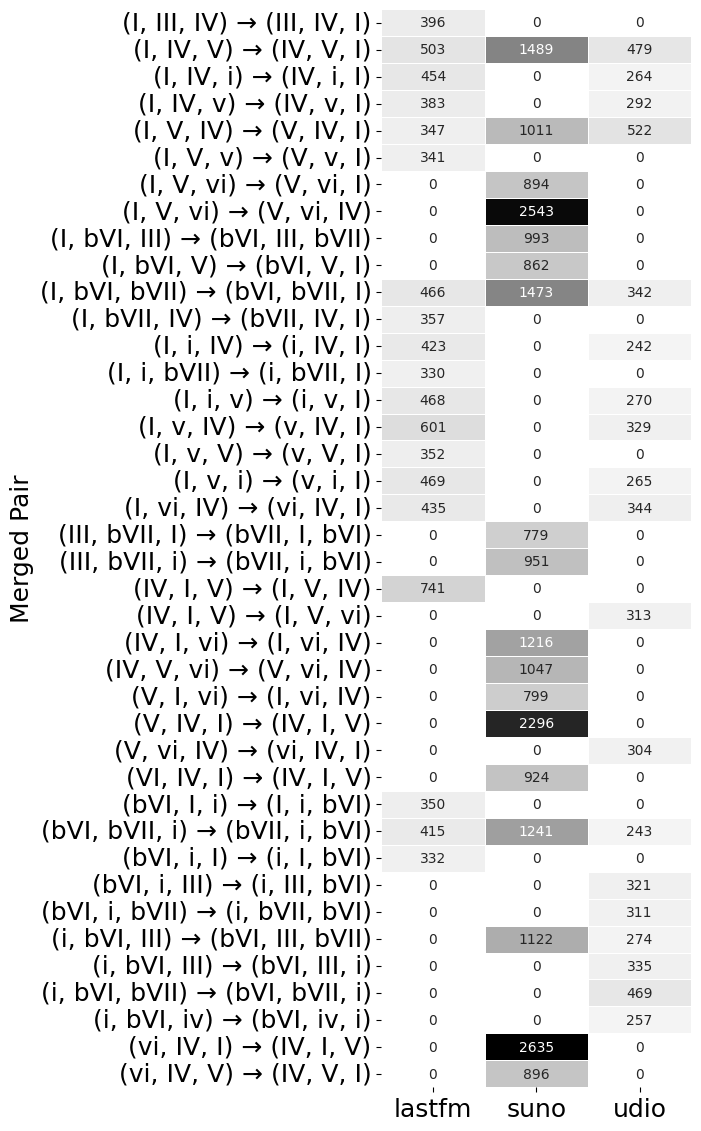

In [37]:
# 🔥 Heat‑map of the first 20 merged pairs per collection — one trigram → one trigram only
def expand_base_trigrams(tok, rules):
    """Return list of base trigrams hidden inside *tok* (MERGE_x or tuple)."""
    return expand_token(tok, rules)

def token_as_text_single(tok, rules):
    """Return printable text; if token expands to >1 trigram, return None (skip)."""
    tris = expand_base_trigrams(tok, rules)
    if len(tris) != 1:          # skip composite tokens
        return None
    tri = tris[0]               # exactly one trigram
    return f"({', '.join(tri)})"

# -------------------------------------------------------------
pair_info = []   # (pair_str, collection, freq)
for col, res in results.items():
    rules = res['rules']
    for (a, b), freq in res['history'][:20]:
        left  = token_as_text_single(a, rules)
        right = token_as_text_single(b, rules)
        if left is None or right is None:
            continue                    # skip complex merges
        pair_str = f"{left} → {right}"
        pair_info.append((pair_str, col, freq))

# unique pairs, sorted safely
pairs = sorted({p for p, _, _ in pair_info})
freq_mat = np.zeros((len(pairs), len(COLLECTIONS)))

for r, pair in enumerate(pairs):
    for c, col in enumerate(COLLECTIONS):
        freq = next((f for p, cc, f in pair_info if p == pair and cc == col), 0)
        freq_mat[r, c] = freq

text_size = 18
t_size    = 18

col_width_in  = 1.0               # width for ONE collection column (inches)
row_height_in = 0.3               # height for ONE trigram row     (inches)

fig_w = col_width_in  * len(COLLECTIONS) + 1.0   # +1 for margins
fig_h = row_height_in * len(pairs)      + 2.0    # +2 for title / xlabel

plt.figure(figsize=(fig_w, fig_h))

sns.heatmap(
    freq_mat,
    xticklabels=COLLECTIONS,
    yticklabels=pairs,
    cmap='Greys',
    annot=True,
    fmt='.0f',
    linewidths=0.4,
    cbar=False          # hide colour bar
)

ax = plt.gca()
ax.set_xticklabels(ax.get_xticklabels(), fontsize=t_size, rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=t_size)  # larger trigram text

# plt.xlabel('', fontsize=18)
plt.ylabel('Merged Pair', fontsize=18)
# plt.title('', fontsize=text_size, pad=16, loc='right')
plt.tight_layout()
plt.show()